## Lecture 5: Parallel Computing 2 — Granularity, Load Balancing & Map-Filter-Reduce

### ****Exercise 1:** Overhead vs. Granularity (25 min)**

****Goal:** Observe how chunk size $L$ affects parallel overhead using Monte Carlo $\pi$.**

In [1]:
# From slide 23


from multiprocessing import Pool
import random
import time
import os


def monte_carlo_chunk(num_samples):
    """Estimate pi contributions for num_samples random points."""
    inside = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside


def test_granularity(total_work, chunk_size, n_proc):
    n_chunks = total_work // chunk_size
    tasks = [chunk_size] * n_chunks
    t0 = time.perf_counter()
    if n_proc == 1:
        results = [monte_carlo_chunk(s) for s in tasks]
    else:
        with Pool(processes=n_proc) as pool:
            results = pool.map(monte_carlo_chunk, tasks)
    return time.perf_counter() - t0, 4 * sum(results) / total_work


if __name__ == '__main__':
    total_work = 1_000_000
    n_proc = os.cpu_count() // 2
    chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
    print(f"{'L':>12} | {'serial (s)':>12} | {'parallel (s)':>12}")
    for L in chunk_sizes:
        t_ser, _ = test_granularity(total_work, L, n_proc=1)
        t_par, pi = test_granularity(total_work, L, n_proc=n_proc)
        print(f"{L:12d} | {t_ser:12.4f} | {t_par:12.4f} pi={pi:.4f}")

           L |   serial (s) | parallel (s)
          10 |       0.1458 |       0.0779 pi=3.1409
         100 |       0.1270 |       0.0664 pi=3.1415
        1000 |       0.1181 |       0.0491 pi=3.1430
       10000 |       0.0869 |       0.0555 pi=3.1454
      100000 |       0.0885 |       0.0575 pi=3.1390
     1000000 |       0.0926 |       0.1268 pi=3.1429


****Setup:****

- **Total work $N$ = const (same total compute regardless of $L$)**

Done. Please see the code above. Here $N = 1,000,000$

- **Vary $L$ from $10$ to $1,000,000$ samples per chunk**

Done. Please see the code above.

- **Test with `P=1` (serial) and `P=os.cpu count()//2` (parallel)**

Done. Please see the code above.

- **Print elapsed time for each configuration**

Done. Please see the code above.

****What to look for:****

- **Serial time: stays roughly flat (computation is constant, no IPC overhead)**

I have decided to plot it.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

total_work = 1_000_000
chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
n_proc = os.cpu_count() // 2

def exercise1_compute():
    times_serial = []
    times_parallel = []
    for L in chunk_sizes:
        t_ser, _ = test_granularity(total_work, L, n_proc=1)
        t_par, _ = test_granularity(total_work, L, n_proc=n_proc)
        times_serial.append(t_ser)
        times_parallel.append(t_par)
    return times_serial, times_parallel

ex1_file = Path("l05_ex1_res.npz")
if not ex1_file.exists():
    serial, parallel = exercise1_compute()
    np.savez(ex1_file, serial=serial, parallel=parallel)

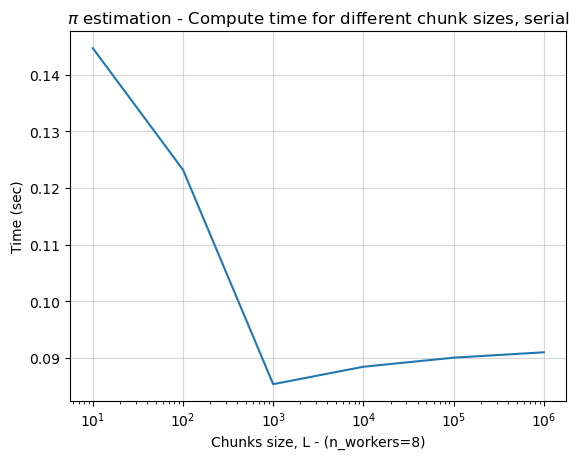

In [3]:
times_serial = np.load(ex1_file)["serial"]

plt.plot(chunk_sizes, times_serial)
plt.xlabel(f"Chunks size, L - (n_workers={n_proc})")
plt.xscale("log")
plt.ylabel("Time (sec)")
plt.grid(alpha=0.5)
plt.title(r"$\pi$ estimation - Compute time for different chunk sizes, serial")

plt.show()

The serial runtime remains relatively flat after the chunk size of $L=1000$.

- **Parallel time: U-shaped curve — high overhead at small $L$, poor balance at large $L$**

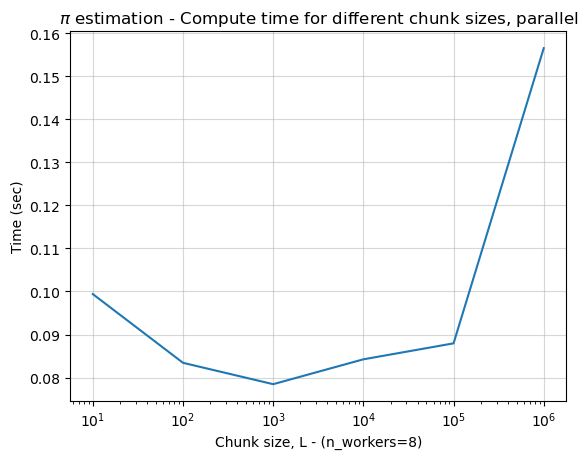

In [4]:
times_serial = np.load(ex1_file)["parallel"]

plt.plot(chunk_sizes, times_serial)
plt.xlabel(f"Chunk size, L - (n_workers={n_proc})")
plt.xscale("log")
plt.ylabel("Time (sec)")
plt.grid(alpha=0.5)
plt.title(r"$\pi$ estimation - Compute time for different chunk sizes, parallel")

plt.show()

We see a somewhat *u*-shape using the log scale.

- **Where is the optimal $L$ for your machine?**

Based on the previous plots, the most optimal chunk size on my machine is $L=1000$ for both the serial and parallel cases.

One can observe from the plot, that the left side suffers from load imbalance while the right side suffers from scheduling overhead.

****Done?** Identify optimal chunk size → discuss with a neighbour**

My peer neighbour had some weird results regarding the parallel case, likely due to how their OS (macOS) spawns new processes using Pythons `Pool`. This resulted in slowdowns compared to their serial results.

When comparing our results, we were both able to identify the optimal chunk size.

### ****Exercise 2:** Serial pipeline → parallel map**

****Data:** $N = 1,000,000$ random integers in $[10, 100]$**

****Pipeline:** map (subtract 7) → filter (keep odd) → reduce (sum)**

In [5]:
# From slide 25

# Setup — data and worker function (module-level for pickling):
import random, time
from functools import reduce
from multiprocessing import Pool

N = 1_000_000
data = [random.randint(10, 100) for _ in range(N)]

def subtract_seven(x):
    return x - 7

#### ****Part 1:** — Serial (10 min):**

In [6]:
# From slide 25

# Part 1 — serial pipeline (map / filter / reduce chained):
t0 = time.perf_counter()
result_ser = reduce(lambda a, b: a + b,
                    filter(lambda x: x % 2 == 1,
                           map(subtract_seven, data)))

t_serial = time.perf_counter() - t0

- **Implement the pipeline using `map()`, `filter()`, `reduce()` built-ins**

Done. Please see the code above.

- **Run and verify the result**

I am unsure what exactly is meant by "verify results", thus I have decided to implement my own using style 3 form slide 18.

In [7]:
result_verify = 0
for x in data:
    sv = subtract_seven(x)      # map
    if sv % 2 == 1:             # filter
        result_verify += sv     # reduce

In [8]:
assert result_verify == result_ser

print(f"Part 1 time (serial): {t_serial:.3f}s")

Part 1 time (serial): 0.113s


#### ****Part 2:** — Parallel (15 min):**

In [9]:
# From slide 25

# Part 2 — replace `map()` with `Pool.map()`:
t0 = time.perf_counter()
with Pool() as pool:
    mapped = pool.map(subtract_seven, data)
result_par = reduce(lambda a, b: a + b,
                    filter(lambda x: x % 2 == 1, mapped))
t_parallel = time.perf_counter() - t0

print(f"Serial:     {t_serial:.4f}s result={result_ser}")
print(f"Parallel:   {t_parallel:.4f}s result={result_par}")
print(f"Speedup:    {t_serial / t_parallel:.2f}x")

Serial:     0.1128s result=24204478
Parallel:   0.2708s result=24204478
Speedup:    0.42x


- ****Before running — predict:** will `Pool.map()` be faster? Why or why not?**

I predict no, since the overhead of scheduling and process creation far outweighs the cost of a simple subtraction.

- **Replace `map(subtract_seven, data)` with `pool.map(subtract_seven, data)`**

Done. Please see the code above.

- **Time both versions and compare**

In [10]:
print(f"Serial:     {t_serial:.4f}s result={result_ser}")
print(f"Parallel:   {t_parallel:.4f}s result={result_par}")
print(f"Speedup:    {t_serial / t_parallel:.2f}x")

Serial:     0.1128s result=24204478
Parallel:   0.2708s result=24204478
Speedup:    0.42x


**After running:**

- **Was your prediction correct?**

Yes.

- **How does this compare to the overhead curve you saw in E1?**

*serial*: Comparing to computing pie with just subtraction seven, the computational cost or workload needed per chunk is *much* lower, resulting in *finer-grained* tasks. Comparing with the optimal runtime from exercise 1, we see a speedup of $\frac{0.095}{0.1128}=0.84\times$ in fact a slowdown. Looking at the serial graph from exercise 1, the result from this exercise would fall on the left side of curve.

*parallel*: The parallel version also suffers from too fine-grained tasks plus the addition of scheduling overhead. Comparing with the optimal runtime from exercise 1, we see a speedup of $\frac{0.089}{0.2708}=0.33\times$ a slowdown in fact, and a much greater slowdown compared to the serial case. Looking at the parallel graph form exercise 1, the result of this exercise would fall left hand side of the curve.

****Done?** Discuss with a neighbour → move on to MP2 milestones**

Noted! I discussed it with my neighbour and they saw the same tendency in their results.

### ****Milestone 1:** Chunked Mandelbrot (20 min)**

****Goal:** Decouple the number of chunks from the number of workers.**

In [ ]:
# From slide 27

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter): ...
@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter): ...
def _worker(args): return mandelbrot_chunk(*args) # plain Python, must be module-level

In [ ]:
# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

****What to do:****

- **Add an `n_chunks` parameter to `mandelbrot_parallel` (default: `n_chunks = n workers`)**

- **Verify output still matches the serial result from L04**

- **Re-run the L04 worker-count benchmark with `n_chunks = 4 × n workers`; note any change**

****Done?** Verify result matches serial output → commit**

### ****Milestone 2:** Optimal Chunk Size (15 min)**

****Fix `n_workers` at your L04 optimum. Sweep `n_chunks`, measure wall time, and compute LIF = $ p \cdot T_p/T_1 − 1 $.****

****Suggested configurations (`n_workers` = your best):****

| **n_chunks** | **time (s)** | **vs. 1×** | **LIF** |
| -------------- | ------------ | ---------- | ------- |
| 1× n workers   | —            | baseline   | —       |
| 2× n workers   | —            | —          | —       |
| 4× n workers   | —            | —          | —       |
| 8× n workers   | —            | —          | —       |
| 16× n workers  | —            | —          | —       |

****Tips:****

- **Use `statistics.median()` of 3+ runs**

- **Include warm-up before timing**

- **LIF minimum = sweet spot**

- **Typical sweet spot: 4–8× `n_workers`**

****Done?** Record optimal `n_chunks` and LIF in performance notebook (MP2) → commit**

### ****Milestone 3:** Comprehensive Analysis (20 min)**

****Create a full performance comparison at $1024×1024$, `max_iter=100`:****

#### ****1 Speedup table:****

| **Implementation** | **Time (s)** | **Speedup** |
| ------------------ | ------------ | ----------- |
| Naive Python       | —            | 1x          |
| Numpy              | —            | —           |
| Numba (@njit)      | —            | —           |
| Parallel (opt.)    | —            | —           |

#### ****2. Speedup vs. core count:****

- **Actual vs. ideal (linear)**
- **Back-solve implied $s = \frac{1/S_p^∗ − 1/p^*}{1 − 1/p^*}$**
- **Is your s smaller than your L04 result?** - Better load balance ⇒ lower apparent $s$?

#### ****3. Brief recommendation:****

- **What settings give the best time?**

- **Is parallelisation worth it on your hardware?** - Compare speedup and LIF to your serial
Numba baseline

- **Write 2–3 sentences in your performance notebook**

#### ****4. Submit to Performance Tracker:****

- **Enter your best multiprocessing time on Moodle - (1024×1024, Implementation: “Multiprocessing”)**

****Done?** Record all results in performance notebook (MP2) → commit**